This script plots the flow duration curves for WS 1, 2, and 3 in the pre-logging period (before 1962) and pre-fire period (2000-2020).

In [ ]:
#imports
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
from scipy.interpolate import interp1d

In [2]:
#set default font to arial
matplotlib.rc('font',family='Arial')

In [ ]:
#inputs
working_directory=r"C:\Users\duffshan\Box\Shannon_Duffy\Writing\Code For Paper Publication"
# filepaths
dailyQfile=os.path.join(working_directory,"Intermediate Outputs","Daily_meanQ_allsites_1950_2025.csv")
outputfolder = os.path.join(working_directory,"Output Figures","Intermediate Figures")

In [ ]:
#read in daily Q
dailyQ_whole=pd.read_csv(dailyQfile)
dailyQ_whole["WATERYEAR"]=pd.to_numeric(dailyQ_whole["WATERYEAR"],errors='coerce',downcast='integer') 
dailyQ_whole["DATE"]=pd.to_datetime(dailyQ_whole["DATE"],errors='coerce')
dailyQ_whole_rename=dailyQ_whole .rename(columns={"GSLOOK":"Lookout Creek","GSWS01":"WS 1","GSWS02":"WS 2","GSWS03":"WS 3","GSWS08":"WS 8","GSWS09":"WS 9","GSWS10":"WS 10","GSWSMC":"Mack Creek"})
ws123_df = dailyQ_whole_rename[['DATE','WS 1', "WS 2", "WS 3","WATERYEAR"]]

C:\Users\duffshan\AppData\Local\Temp\ipykernel_32660\2814088654.py:37: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df=groups_prelogging.get_group((wateryear))
C:\Users\duffshan\AppData\Local\Temp\ipykernel_32660\2814088654.py:67: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df=groups_prefire.get_group((wateryear))
C:\Users\duffshan\AppData\Local\Temp\ipykernel_32660\2814088654.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


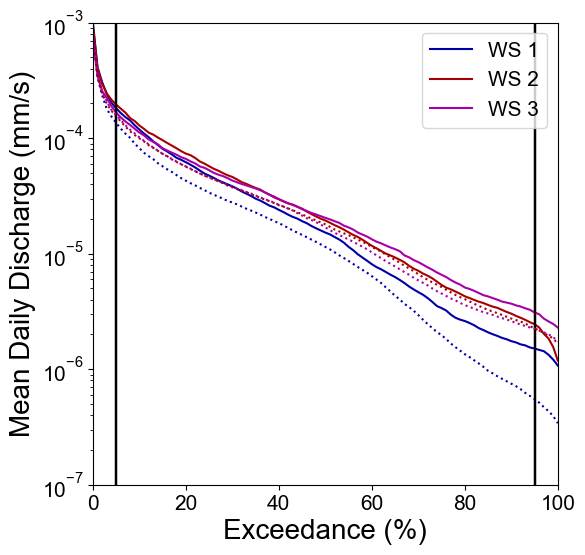

In [ ]:
#break into pre and post logging and pre and post fire
ws123_df=ws123_df.dropna()
ws123_prelogging = ws123_df[ws123_df['WATERYEAR']<1962]
ws123_postlogging = ws123_df[ws123_df['WATERYEAR']>=1962]
ws123_postlogging = ws123_postlogging[ws123_postlogging['WATERYEAR']<1971]
ws123_prefire = ws123_df[ws123_df['WATERYEAR']>=1999]
ws123_prefire = ws123_prefire[ws123_prefire['WATERYEAR']<2021]
ws123_postfire = ws123_df[ws123_df['WATERYEAR']>2021]

# create dictionary of colors that match watersheds
color_dict_123 = {"WS 1":"#0000A8","WS 2":"#a80000","WS 3": "#A800A8"}
groups_prelogging = ws123_prelogging.groupby(["WATERYEAR"])
exceedence_probs = np.linspace(0,1,num=101)

fig2=plt.figure(figsize=(6,6))
for watershed in ws123_prelogging:
    if watershed == "WS 1" or watershed == "WS 2" or watershed == "WS 3":
        plt.xlabel("Exceedance (%)", fontsize=20)
        plt.ylabel("Mean Daily Discharge (mm/s)", fontsize=20)
        plt.ylim(1*10**(-7),1*10**(-3))
        plt.xlim((0,100))
        plt.yscale("log")
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.axvline(x=5, color = "black")
        plt.axvline(x=95, color = "black")
        interp_exceedences=[]
        for wateryear in ws123_prelogging["WATERYEAR"].unique():
            df=groups_prelogging.get_group((wateryear))
            sort=np.sort(df[watershed])[::-1]
            sort=sort[~np.isnan(sort)]
            exceedence = np.arange(1.,len(sort)+1) / len(sort)
            interp_func=interp1d(exceedence[::-1],sort[::-1],kind="linear",fill_value="extrapolate")
            interpQ=interp_func(exceedence_probs)
            interp_exceedences.append(interpQ)
        exceedence_df=pd.DataFrame(interp_exceedences,columns=[exceedence_probs])
        mean_exceedences=[]
        for columnName in exceedence_df:
            mean=exceedence_df[columnName].mean()
            mean_exceedences.append(mean)
        plt.plot(exceedence_probs*100, mean_exceedences,label=watershed, color=color_dict_123[watershed])
    else:
        continue

groups_prefire = ws123_prefire.groupby(["WATERYEAR"])
for watershed in ws123_prefire:
    if watershed == "WS 1" or watershed == "WS 2" or watershed == "WS 3":
        plt.xlabel("Exceedance (%)", fontsize=20)
        plt.ylabel("Mean Daily Discharge (mm/s)", fontsize=20)
        plt.ylim(1*10**(-7),1*10**(-3))
        plt.xlim((0,100))
        plt.yscale("log")
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.axvline(x=5, color = "black")
        plt.axvline(x=95, color = "black")
        interp_exceedences=[]
        for wateryear in ws123_prefire["WATERYEAR"].unique():
            df=groups_prefire.get_group((wateryear))
            sort=np.sort(df[watershed])[::-1]
            sort=sort[~np.isnan(sort)]
            exceedence = np.arange(1.,len(sort)+1) / len(sort)
            interp_func=interp1d(exceedence[::-1],sort[::-1],kind="linear",fill_value="extrapolate")
            interpQ=interp_func(exceedence_probs)
            interp_exceedences.append(interpQ)
        exceedence_df=pd.DataFrame(interp_exceedences,columns=[exceedence_probs])
        mean_exceedences=[]
        for columnName in exceedence_df:
            mean=exceedence_df[columnName].mean()
            mean_exceedences.append(mean)
        plt.plot(exceedence_probs*100, mean_exceedences, color=color_dict_123[watershed],linestyle="dotted")
    else:
        continue
plt.legend(fontsize=15,loc="upper right")
fig2.show()

In [ ]:
#export figure
output_path = os.path.join(outputfolder, f"FigS3_FDC_curves_WS123.png")
fig2.savefig(output_path,bbox_inches='tight')